## Preparing System


### Mounting Gdrive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Installing Julia

In [2]:
!curl -sSL "https://julialang-s3.julialang.org/bin/linux/x64/1.4/julia-1.4.0-linux-x86_64.tar.gz" -o julia.tar.gz
!tar -xzf julia.tar.gz -C /usr --strip-components 1
!rm -rf julia.tar.gz*

### Installing libraries

In [3]:
!julia -e 'using Pkg;ENV["JUPYTER"]="/usr/local/bin/python" ;pkg"add IJulia,Distributions,Plots,LaTeXStrings,PyCall,StatsBase,PyPlot,KernelDensity;precompile"'

    Cloning default registries into `~/.julia`
    Cloning registry from "https://github.com/JuliaRegistries/General.git"
      Added registry `General` to `~/.julia/registries/General`
  Resolving package versions...
  Installed LaTeXStrings ───────────────── v1.3.0
  Installed PyPlot ─────────────────────── v2.11.0
  Installed KernelDensity ──────────────── v0.6.5
  Installed PyCall ─────────────────────── v1.94.1
  Installed StatsBase ──────────────────── v0.33.21
  Installed IJulia ─────────────────────── v1.23.3
  Installed Plots ──────────────────────── v1.6.12
  Installed Distributions ──────────────── v0.25.45
  Installed NetworkOptions ─────────────── v1.2.0
  Installed OpenLibm_jll ───────────────── v0.7.1+0
  Installed IteratorInterfaceExtensions ── v1.0.0
  Installed OpenSSL_jll ────────────────── v1.1.1+6
  Installed Tables ─────────────────────── v1.7.0
  Installed NaNMath ────────────────────── v0.3.7
  Installed IterTools ──────────────────── v1.4.0
  Installed SpecialF

## Installing python requirements to run julia in notebook

In [4]:
!pip install julia 

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 67 kB 4.2 MB/s 


In [5]:
import julia
julia.install()

j = julia.Julia(compiled_modules=False)

%load_ext julia.magic

Initializing Julia interpreter. This may take some time...


In [6]:
from julia import Main as jl

 ## Load julia modules
 

In [7]:
%%julia
;

In [8]:
%%julia 
using Distributed
#addprocs(5)

@everywhere using Distributed,Distributions,StatsBase,Printf,Random 

#using Distributed
#using Distributions,StatsBase,Printf,Random 

using Plots
using PyCall
using Serialization
using KernelDensity

pd = pyimport("pandas")

Plots.backend()

pyplot();

## Load ABM model

In [9]:
%%julia

rootDir=pwd()*"/drive/MyDrive/SYNC_Projects/"

rootDir=rootDir*"pBGT/ms/"

source_path=rootDir*"code/ABM/source/"
workingDir=rootDir*"pBGT/ms/code/Figure_7/"
pathData=rootDir*"data/sim_data/survival/"
pathFigures=rootDir*"figures/"

#push!(LOAD_PATH,source_path)
source_path,workingDir

('/content/drive/MyDrive/SYNC_Projects/pBGT/ms/code/ABM/source/',
 '/content/drive/MyDrive/SYNC_Projects/pBGT/ms/pBGT/ms/code/Figure_7/')

In [10]:
%%julia

include(source_path*"ModelParameters.jl")
include(source_path*"Bacterias.jl")
include(source_path*"CellularFunctions.jl")
include(source_path*"Simulator.jl")
include(source_path*"AnalysisFunctions.jl")
include(source_path*"PlottingFunctions.jl")


## Simulation paramters

In [11]:
%%julia


aA=0.

starting_variation=false
iniCells=100000

mus=collect(0:100)
cvs=collect(0:0.05:1)
ics=collect(0:0.05:3)

;

## Simple calculation
### Survival for n individual antibiotic shocks

 ### Computing distributions for pBGT parameters

In [12]:
%%julia 
pBGT_survival_probability_file=pathData*"pBGT_survival_probability"
pBGT_survival_plasmids_file=pathData*"pBGT_survival_plasmids"
pBGT_survival_aliveplasmids_file=pathData*"pBGT_survival_aliveplasmids"
pBGT_run_params_file=pathData*"pBGT_run_params"
pBGTmu=19.

pMIC=getMIC(pBGTmu)

reDo_sim=true
reDo_sim=false

if reDo_sim
    nrepeats=10

    pBGT_cv_ic_sprob=[]
    pBGT_cv_ic_plasmids_all=[]
    pBGT_cv_ic_plasmids_alive=[]

    stric=""
    for x in ics
        global stric
        tstr=@sprintf("%0.2f ",x)
        stric=stric*tstr
    end

    println("mu,    cv\t$stric   <- ICs")
    for cv in cvs
        p_NdistP=Normal(pBGTmu,pBGTmu*cv)

    print("$mu, $cv\t")
        ic_sprob=[]
        ic_plasmids_all=[]
        ic_plasmids_alive=[]

        for ic in ics
            aAi=pMIC*ic
            n_total=iniCells
            n_alive=0

            plasmids_all=[]
            plasmids_alive=[]

            for rep in 1:nrepeats
                bst=getInitialPopulation(iniCells, mu, 1,starting_variation);
                #bst=getInitialPopulationParallel(iniCells, mu, 1,p_NdistP,starting_variation);
                for b in bst
                    rep==1 ? push!(plasmids_all,b.plasmids[2]) : 0
                    b.isDead = antibiotic_dynamics(b,aAi)
                    b.isDead==false ? (n_alive+=1; ) : 0
                    (b.isDead==false&&rep==1) ? (push!(plasmids_alive,b.plasmids[2]) ) : 0
                end
            end

            sprob=n_alive/(n_total*nrepeats)
            str=@sprintf("%0.2f ",round(sprob,digits=2) )
            print(str)
            push!(ic_sprob,sprob)
            push!(ic_plasmids_all,plasmids_all)
            push!(ic_plasmids_alive,plasmids_alive)
        end #end ic
        println()
        push!(pBGT_cv_ic_sprob,ic_sprob)
        push!(pBGT_cv_ic_plasmids_all,ic_plasmids_all)
        push!(pBGT_cv_ic_plasmids_alive,ic_plasmids_alive)

    end

    serialize(pBGT_survival_probability_file, pBGT_cv_ic_sprob);
    serialize(pBGT_survival_plasmids_file, pBGT_cv_ic_plasmids_all);
    serialize(pBGT_survival_aliveplasmids_file, pBGT_cv_ic_plasmids_alive);
    serialize(pBGT_run_params_file,[mus,cvs,ics])
    println("Simulation finished!")
    
else
    pBGT_cv_ic_sprob=deserialize(pBGT_survival_probability_file)
    pBGT_cv_ic_plasmids_all=deserialize(pBGT_survival_plasmids_file)
    pBGT_cv_ic_plasmids_alive=deserialize(pBGT_survival_aliveplasmids_file)
    this_params=deserialize(pBGT_run_params_file)   
    mus=this_params[1]
    cvs=this_params[2]
    ics=this_params[3]   
    println("Loaded pBGT Survival variables.")
end

;


Loaded pBGT Survival variables.


In [13]:
%matplotlib inline
# important

### Ploting Kaplan-Meier for  pBGT $\mu$ and $\sigma$s

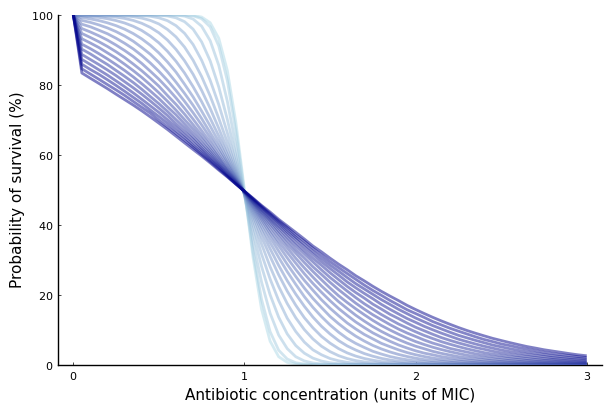

In [14]:
%%julia

muipBGT=findall(x -> x == 19., mus)[1]
cvipBGT=findall(x -> x == 0.25, cvs)[1]
pBGTcv=cvs[cvipBGT]


cm = cgrad(:blues)
colors = [cm[i] for i in range(0,stop=1,length=length(cvs))]
doses=ics
this_probs0=pBGT_cv_ic_sprob[cvipBGT]

pp=plot(size=(600,400))

#Different cvs
for cvi in collect(1:length(cvs))
    
    this_probs = pBGT_cv_ic_sprob[cvi]
    
    
    plot!(pp,doses, 100*this_probs, alpha=.5,  
            color=colors[cvi], legend=:none,
            xlabel = "Antibiotic concentration (units of MIC)",ylabel="Probability of survival (%)",
            ylims = (0,100), grid=false, linewidth=2)
end
display(pp)

Saving figure /content/drive/MyDrive/SYNC_Projects/pBGT/ms/figures/Fig-7C.pdf ..


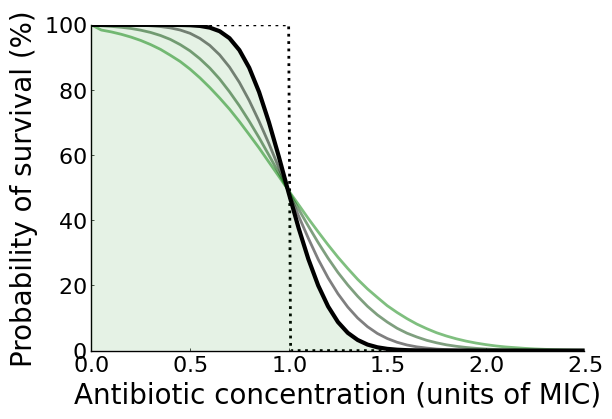

In [15]:
%%julia

muipBGT=findall(x -> x == 19., mus)[1]
cvipBGT=findall(x -> x == 0.15, cvs)[1]
pBGTcv=cvs[cvipBGT]

cvsl=[.25,.35,.45]

cm = cgrad(:linear_ternary_green_0_46_c42_n256)
colors = [cm[i] for i in range(0,stop=1,length=length(cvsl))]
doses=ics

this_probs0=[]
dosesl=collect(0:.01:3)
for x in dosesl
    val=1
    x<=1 ? val=1 : val=0
    push!(this_probs0,val)
end
p=plot(dosesl, 100*this_probs0, alpha=1,  
            color="black", legend=:none, line=:dot,
            xlabel = "Antibiotic concentration (units of MIC)",ylabel="Probability of survival (%)",
            ylims = (0,100), grid=false, linewidth=2)


i=0

for cv in cvsl
    global i
    cvi=findall(x -> x == cv, cvs)[1]
    this_probs = pBGT_cv_ic_sprob[cvi]
    i=1+i
    
    plot!(doses, 100*this_probs, alpha=.5,  
          #  color=colors[cvi], legend=:none,
            color=colors[i], legend=:none,
            xlabel = "Antibiotic concentration (units of MIC)",ylabel="Probability of survival (%)",
            ylims = (0,100), grid=false, linewidth=2)
end
this_probs0=pBGT_cv_ic_sprob[cvipBGT]
plot!(doses, 100*this_probs0, alpha=1.,  
            color="black", legend=:none, fillalpha=0.1, fillrange=0, fillcolor="green",
            xlabel = "Antibiotic concentration (units of MIC)",ylabel="Probability of survival (%)",
            xtickfontsize=16,ytickfontsize=16,xguidefontsize=20,yguidefontsize=20,legendfontsize=16,
            ylims = (0,100),xlims = (0,2.5), grid=false, linewidth=3)


#plot!(size=(2000,1000),dpi=200)

figname=pathFigures*"Fig-7C.pdf"
println("Saving figure $figname ..")
savefig(p,figname)
display(p)



cv=0.2, cv=0.25, cv=0.35, 
Saving figure /content/drive/MyDrive/SYNC_Projects/pBGT/ms/figures/Fig-7B.pdf ..


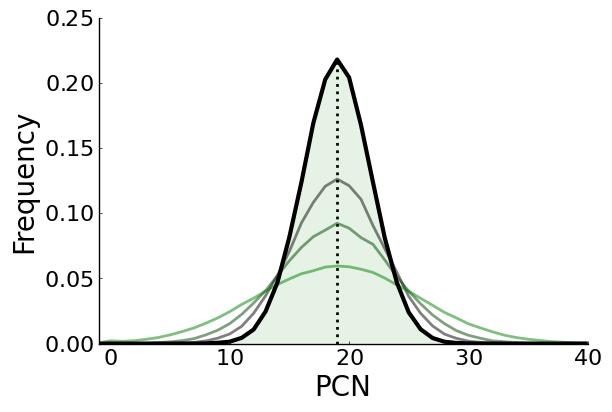

In [21]:
%%julia
cvsl=[.2,.25,.35]
bins=collect(-1:40)
cm = cgrad(:linear_ternary_green_0_46_c42_n256)
colors = [cm[i] for i in range(0,stop=1,length=length(cvsl))]


ps=plot([pBGTmu, pBGTmu],[0., 0.22], alpha=1,color="black", legend=:none, line=:dot, grid=false, linewidth=2)
i=0
for cv in cvsl
    global i
    i+=1
    cvi=findall(x -> x == cv, cvs)[1]
    this_cv=cvs[cvi]

    print("cv=$(this_cv), ")#
    this_plasmids=pBGT_cv_ic_plasmids_all[cvi][1]
    
    tp=[x for x in this_plasmids]
    #nfit=fit(Normal, (tp))
    #dist_0=Normal(nfit.μ,nfit.σ)
    k=kde(tp)
    ik=InterpKDE(k)
    dist_0=pdf(ik,bins)
    plot!(bins,dist_0,  fillrange=0, fillalpha=0., alpha=.5,legend=:none,  
            color=colors[i], label="$(this_cv)", grid=false, xlims = (0., 40),ylabel="Frequency", xlabel="Plasmid copy number", linewidth=2)
end
println()


this_plasmids=pBGT_cv_ic_plasmids_all[cvipBGT][1]
tp=[x for x in this_plasmids]
#nfit=fit(Normal, (tp))
#dist_0=Normal(nfit.μ,nfit.σ)
k=kde(tp)
ik=InterpKDE(k)
dist_0=pdf(ik,bins)
plot!(bins,dist_0, fillrange=0, fillalpha=0.1, alpha=1,  legend=:none, fillcolor="green",
            xtickfontsize=16,ytickfontsize=16,xguidefontsize=20,yguidefontsize=20,legendfontsize=16,
            color="black", label="$(pBGTcv)", grid=false, xlims = (-1., 40),ylabel="Frequency", xlabel="PCN", linewidth=3,
    ylims=(0,0.25))

#px=plot(p, ps, layout = grid(1,2,widths = [0.5,0.50], link=:both), size = (1200, 400))
figname=pathFigures*"Fig-7B.pdf"
println("Saving figure $figname ..")
savefig(ps,figname)
display(ps)


### Plotting $\sigma$ distrubutions

### Plotting  distrubutions changes

21
ic=1.0* 
23
ic=1.1* 
25
ic=1.2* 
27
ic=1.3* 
29
ic=1.4* 
31
ic=1.5* 

Saving figure /content/drive/MyDrive/SYNC_Projects/pBGT/ms/figures/Fig-7E.pdf ..

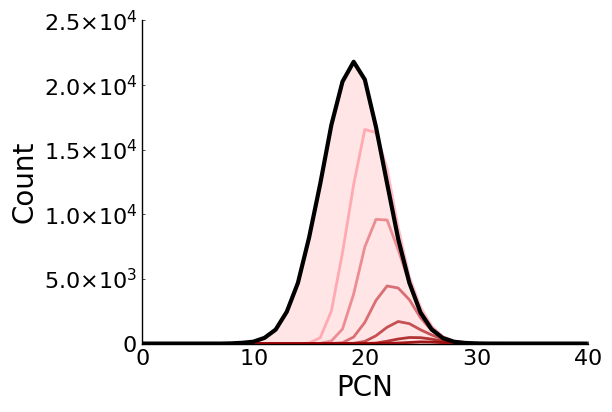

In [17]:
%%julia
bins=collect(0:40)
cm = cgrad(:reds)

#plot_icis=findall(x -> x%0.5==0 , ics)
plot_icis=[21, 23, 25, 27, 29, 31]
color_icis=[1,2,3,4,5,6]

colors = [cm[i] for i in range(0,stop=1,length=length(plot_icis))]

ps=plot([pBGTmu, pBGTmu],[0., 0.25], alpha=1,color="black", legend=:none, line=:dot, grid=false, linewidth=2)

for i in color_icis
    ici=plot_icis[i]
    this_ic=ics[ici]
    println(ici)
    

    print("ic=$(this_ic)")#
    this_plasmids=pBGT_cv_ic_plasmids_alive[cvipBGT][ici]
    this_color=colors[i]
    
    tp=[x for x in this_plasmids]
    meanPCN=mean(this_plasmids)
    
    isempty(tp) ? (print(" ");continue) : 0
    np=length(tp)
    print("* \n")
    k=kde(tp)
    ik=InterpKDE(k)
    dist_0=pdf(ik,bins)
    plot!(bins,dist_0*np, fillrange=0, fillalpha=0., alpha=.9,legend=:none, color=this_color, label="$(this_ic)", grid=false, ylabel="Frequency", xlabel="Plasmid copy number", linewidth=2)

end
println()


this_plasmids=pBGT_cv_ic_plasmids_all[cvipBGT][1]
tp=[x for x in this_plasmids]
#nfit=fit(Normal, (tp))
#dist_0=Normal(nfit.μ,nfit.σ)
np=length(tp)
k=kde(tp)
ik=InterpKDE(k)
dist_0=pdf(ik,bins)
plot!(bins,dist_0*np,  fillrange=0, fillalpha=0.1, alpha=1, fillcolor="red", legend=:none,
            xtickfontsize=16,ytickfontsize=16,xguidefontsize=20,yguidefontsize=20,legendfontsize=16,
            color="black", label="$(pBGTcv)", grid=false, ylims=(0, 2.5e4), xlims = (0., 40),ylabel="Count", xlabel="PCN", linewidth=3,
    #ylims=(0,0.5)
)
#plot!(size=(2000,1000),dpi=200)

figname=pathFigures*"Fig-7E.pdf"
println("Saving figure $figname ..")
savefig(ps,figname)
display(ps)



In [18]:
%%julia
bins=collect(0:40)
cm = cgrad(:reds)
plot_icis=1:31
meanPCNs=[]
stdPCNs=[]
As=[]
for ici in plot_icis
    this_ic=ics[ici]

    print("\nic=$(this_ic)")#
    this_plasmids=pBGT_cv_ic_plasmids_alive[cvipBGT][ici]
    
    tp=[x for x in this_plasmids]
    this_meanPCN=mean(this_plasmids)
    this_stdPCN=std(this_plasmids)
    print("\tmeanPCN=$(this_meanPCN)")
    print("\tstdPCN=$(this_stdPCN)")

    append!(meanPCNs, this_meanPCN)
    append!(stdPCNs, this_stdPCN)
    append!(As, this_ic)
    
end

p=plot(As, meanPCNs, alpha=1,  
            xlabel = "Antibiotic concentration (units of MIC)", ylabel="Mean PCN",
            color="black", legend=:none, line=-,
            xtickfontsize=16,ytickfontsize=16,xguidefontsize=20,yguidefontsize=20,legendfontsize=16,
            ylims = (15,30), xlims=(0, ics[last(plot_icis)]), grid=false, linewidth=2)

plot!(As, meanPCNs.-stdPCNs, fillrange = meanPCNs.+stdPCNs, fillalpha = 0.1, c = "red", fillcolor="red", linewidth=0.5)
plot!(As, meanPCNs.+stdPCNs, c = "red", linewidth=0.5)

# figname=pathFigures*"Fig-7F.pdf"
# println("Saving figure $figname ..")
# savefig(p,figname)
# display(p)




ic=0.0	meanPCN=18.99346	stdPCN=2.862470814836662
ic=0.05	meanPCN=19.02122	stdPCN=2.865057032088185
ic=0.1	meanPCN=18.99988	stdPCN=2.862813640916825
ic=0.15	meanPCN=18.98783	stdPCN=2.8647415168806476
ic=0.2	meanPCN=18.98259	stdPCN=2.8615570546448628
ic=0.25	meanPCN=18.98705	stdPCN=2.853875215130728
ic=0.3	meanPCN=19.00009	stdPCN=2.862749018901136
ic=0.35	meanPCN=18.992569925699257	stdPCN=2.86252313096706
ic=0.4	meanPCN=19.01885094254713	stdPCN=2.8692801581320944
ic=0.45	meanPCN=19.003270948575086	stdPCN=2.8570383449351033
ic=0.5	meanPCN=19.018845264664378	stdPCN=2.8572626029687873
ic=0.55	meanPCN=19.030751171353753	stdPCN=2.8282191560166834
ic=0.6	meanPCN=19.052462785913107	stdPCN=2.8080599767303602
ic=0.65	meanPCN=19.131998898734565	stdPCN=2.7457195330420374
ic=0.7	meanPCN=19.21664341198276	stdPCN=2.671606941281012
ic=0.75	meanPCN=19.390132925996944	stdPCN=2.5803083481279803
ic=0.8	meanPCN=19.58306091440674	stdPCN=2.4814236629426465
ic=0.85	meanPCN=19.8697144443463	stdPCN=2.370781773

<PyCall.jlwrap Plot{Plots.PyPlotBackend() n=3}>

<Figure size 432x288 with 0 Axes>

In [19]:
%%julia
bins=collect(0:40)

bin_edges=collect(0:1:30)

#time_Pcounts_bins=normalize_FullTimeSeries(time_Pcounts,time_mins,bin_edges)


cmr = cgrad(:reds)
plot_icis=1:31
meanPCNs=[]
stdPCNs=[]
As=[]
ic_Pcounts=[]
for ici in plot_icis
    this_ic=ics[ici]

    this_plasmids=pBGT_cv_ic_plasmids_alive[cvipBGT][ici]
    
    this_meanPCN=mean(this_plasmids)
    tp=[x for x in this_plasmids]
    
    append!(meanPCNs, this_meanPCN)
    push!(ic_Pcounts, this_plasmids)
    #ic_Pcounts=hcat(ic_Pcounts, this_plasmids)
    append!(As, this_ic)
    
end

as_Pcounts_bins=normalize_FullTimeSeries(ic_Pcounts,As,bin_edges)
;


Saving figure /content/drive/MyDrive/SYNC_Projects/pBGT/ms/figures/Fig-7F.pdf ..


/usr/local/lib/python3.7/dist-packages/julia/magic.py:130: UserWarning: The following kwargs were not used by contour: 'label'
  )(self.shell.user_ns, caller_frame.f_locals)
/usr/local/lib/python3.7/dist-packages/julia/magic.py:130: UserWarning: The following kwargs were not used by contour: 'label'
  )(self.shell.user_ns, caller_frame.f_locals)


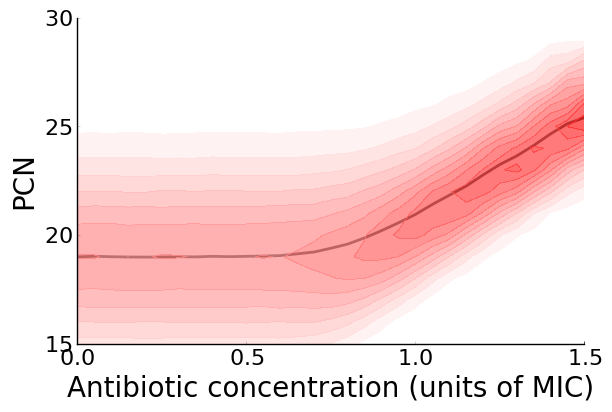

In [20]:
%%julia

colGRAD=cgrad([colorant"white",colorant"blue"])
colGRAD=cgrad([colorant"white",colorant"red"])
pdenmax=ceil(maximum(as_Pcounts_bins),digits=1)

p=plot(As, meanPCNs, alpha=1,  
            xlabel = "Antibiotic concentration (units of MIC)", ylabel="PCN",
            color="black", legend=:none, line=-,
            xtickfontsize=16,ytickfontsize=16,xguidefontsize=20,yguidefontsize=20,legendfontsize=16,
            ylims = (15,30), xlims=(0, ics[last(plot_icis)]), grid=false, linewidth=2)
#heatmap!(p,As,bin_edges,as_Pcounts_bins,colorbar=false, color=colGRAD,alpha=.75)
contour!(p,As,bin_edges,as_Pcounts_bins,colorbar=false,fill=true,lw=0, color=colGRAD,alpha=.75, clim=(.01,pdenmax))


figname=pathFigures*"Fig-7F.pdf"
println("Saving figure $figname ..")
savefig(p,figname)
display(p)


